Structure of the notebook
1. Imports
2. Load datasets
3. Define plotting configs
4. Create histogram ratio function
5. Produce ratio plots
6. Physics observations

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
#load data

DATA_DIR = Path("../SMEFT_bbyy_h5files")

In [3]:
#loader function

def load_h5_to_df(filepath):

    with h5py.File(filepath, "r") as f:

        data = f["ForAnalysis/1d"][:]

    return pd.DataFrame(data)

In [4]:
#load samples

samples = {
    "SM": "new_input_bbyy_SMEFT_SM_4thMarch_2026.h5",
    "cbbim": "new_input_bbyy_SMEFT_cbbim_4thMarch_2026.h5",
    "cbgim": "new_input_bbyy_SMEFT_cbgim_4thMarch_2026.h5",
    "cbhim": "new_input_bbyy_SMEFT_cbhim_4thMarch_2026.h5",
    "chbtil": "new_input_bbyy_SMEFT_chbtil_4thMarch_2026.h5",
    "chgtil": "new_input_bbyy_SMEFT_chgtil_4thMarch_2026.h5",
    "ctbim": "new_input_bbyy_SMEFT_ctbim_4thMarch_2026.h5"
}

In [5]:
#create dataframes

dfs = {}

for label, filename in samples.items():

    dfs[label] = load_h5_to_df(DATA_DIR / filename)

In [6]:
#fix signed_DeltaPhi_jj

for label, df in dfs.items():

    df["signed_DeltaPhi_jj_centered"] = np.where(
        df["signed_DeltaPhi_jj"] > np.pi,
        df["signed_DeltaPhi_jj"] - 2*np.pi,
        df["signed_DeltaPhi_jj"]
    )

In [16]:
#define plot configurations

plot_configs = {

    "DPhi_bb": {
        "range": (0, np.pi),
        "xlabel": r"$\Delta\phi_{bb}$"
    },

    "signed_DeltaPhi_jj": {
        "range": (0, 2 * np.pi),
        "xlabel": r"Signed $\Delta\phi_{jj}$"
    },

    "costheta1": {
        "range": (-1, 1),
        "xlabel": r"$\cos\theta_1$"
    },

    "costheta2": {
        "range": (-1, 1),
        "xlabel": r"$\cos\theta_2$"
    },

    "m_bbyy": {
        "range": (200, 1400),
        "xlabel": r"$m_{bb\gamma\gamma}$ [GeV]"
    },

    "M_jj": {
        "range": (0, 750),
        "xlabel": r"$M_{jj}$ [GeV]"
    },

    "Higgs_pT": {
        "range": (0, 500),
        "xlabel": r"$p_T^H$ [GeV]"
    },

    "Eta_jj": {
        "range": (-5, 5),
        "xlabel": r"$\eta_{jj}$"
    },

    "Phi1": {
        "range": (-np.pi, np.pi),
        "xlabel": r"$\Phi_1$"
    }
}

In [17]:
#--------------------------------
# create raio plot function
#-----------------------------------

def plot_ratio(
    dfs,
    observable,
    bins=40
):

    config = plot_configs[observable]

    x_range = config["range"]

    plt.figure(figsize=(8,6))

    # --- SM histogram ---

    sm_values = dfs["SM"][observable]

    sm_hist, bin_edges = np.histogram(
        sm_values,
        bins=bins,
        range=x_range,
        density=True
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # --- BSM ratios ---

    for label, df in dfs.items():

        if label == "SM":
            continue

        bsm_hist, _ = np.histogram(
            df[observable],
            bins=bins,
            range=x_range,
            density=True
        )

        # Avoid divide-by-zero

        ratio = np.divide(
            bsm_hist,
            sm_hist,
            out=np.ones_like(bsm_hist),
            where=sm_hist > 0
        )

        plt.step(
            bin_centers,
            ratio,
            where="mid",
            linewidth=2,
            label=label
        )

    # --- Unity line ---

    plt.axhline(
        1.0,
        linestyle="--",
        color="black"
    )

    # --- Grey ±10% band ---

    plt.fill_between(
        bin_centers,
        0.9,
        1.1,
        color="gray",
        alpha=0.3
    )

    plt.xlabel(config["xlabel"])

    plt.ylabel("BSM / SM")

    plt.title(f"Ratio Plot: {observable}")

    plt.ylim(0, 2)

    plt.grid(alpha=0.3)

    plt.legend()

    plt.show()

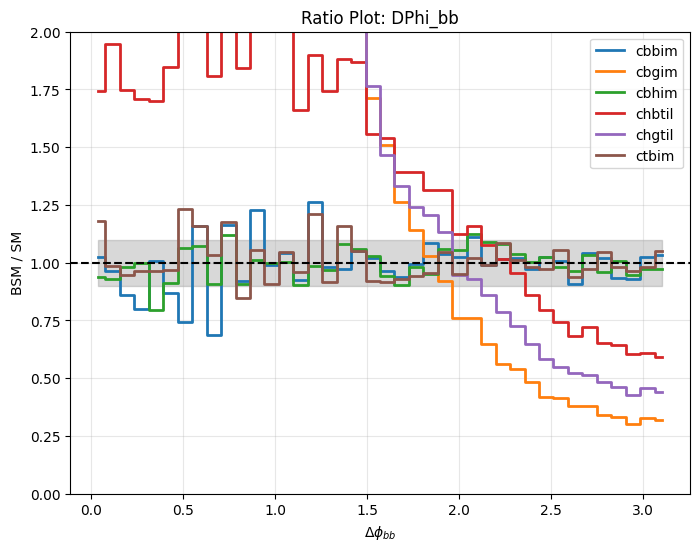

In [18]:
plot_ratio(dfs, "DPhi_bb")

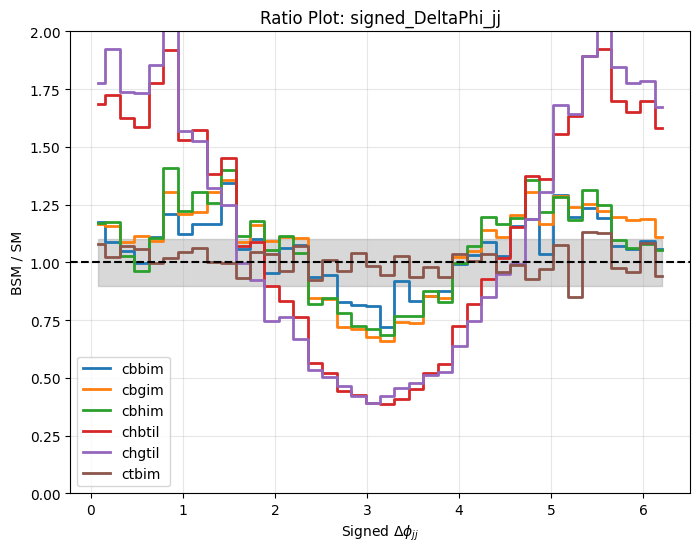

In [19]:
plot_ratio(dfs, "signed_DeltaPhi_jj")

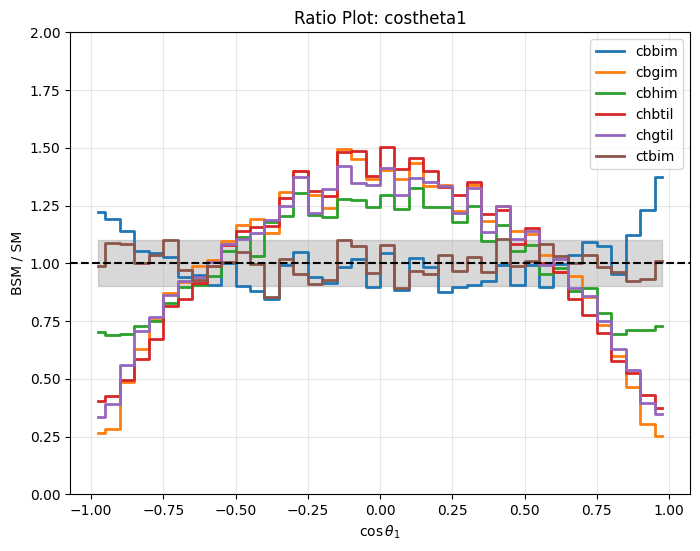

In [20]:
plot_ratio(dfs, "costheta1")

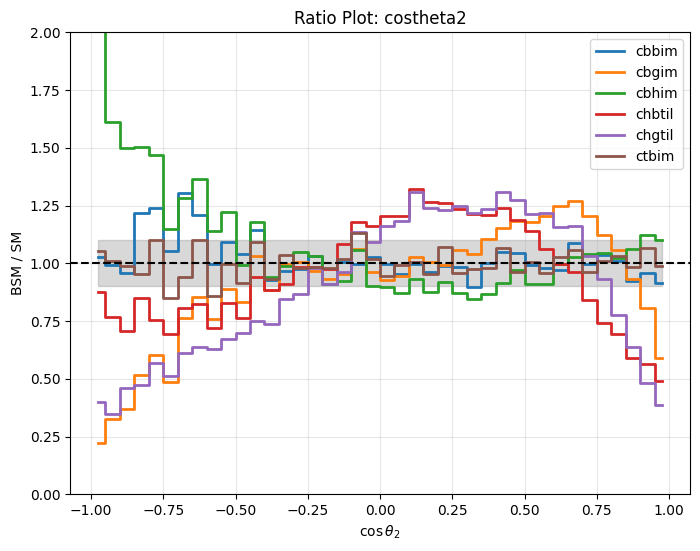

In [21]:
plot_ratio(dfs, "costheta2")

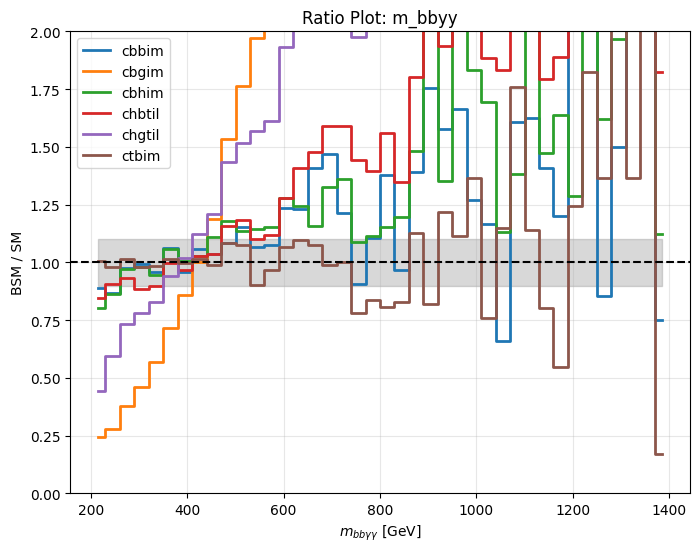

In [22]:
plot_ratio(dfs, "m_bbyy")

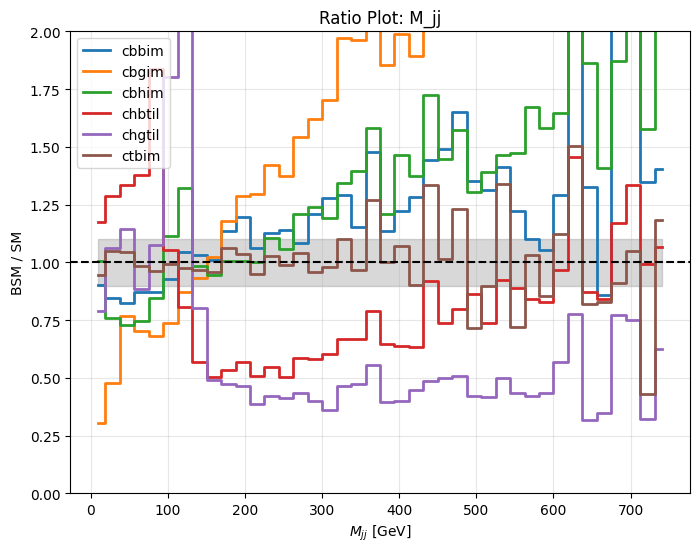

In [23]:
plot_ratio(dfs, "M_jj")

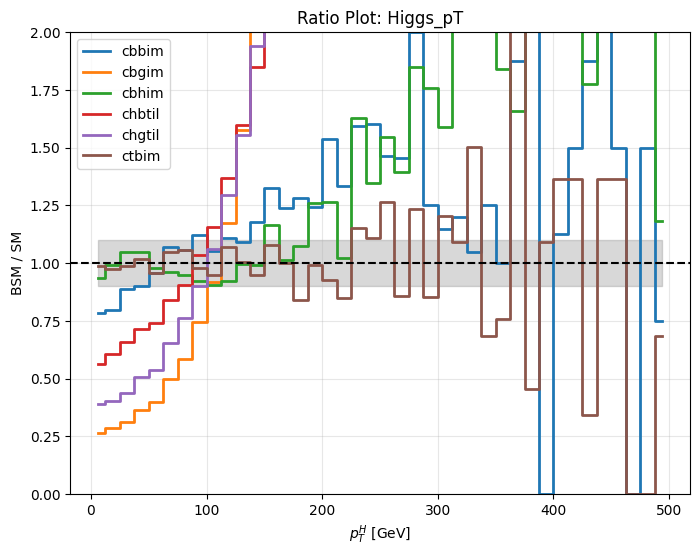

In [24]:
plot_ratio(dfs, "Higgs_pT")

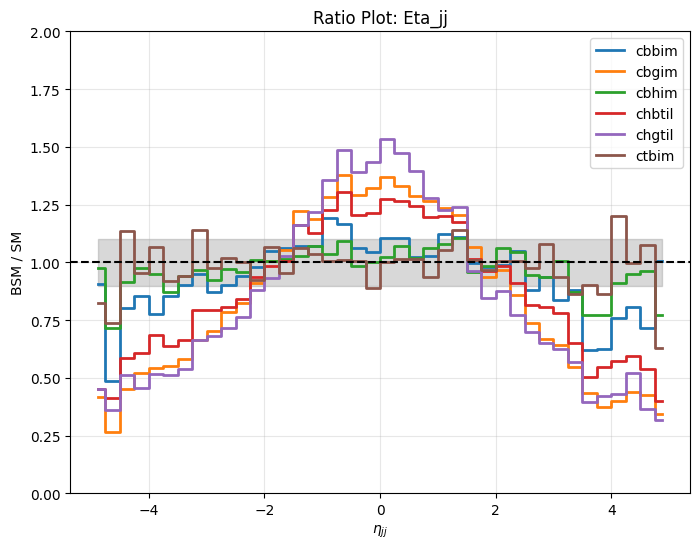

In [25]:
plot_ratio(dfs, "Eta_jj")

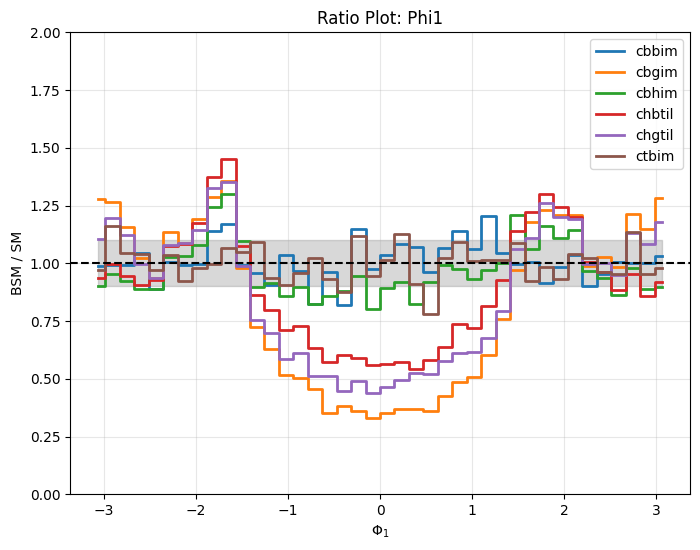

In [26]:
plot_ratio(dfs, "Phi1")

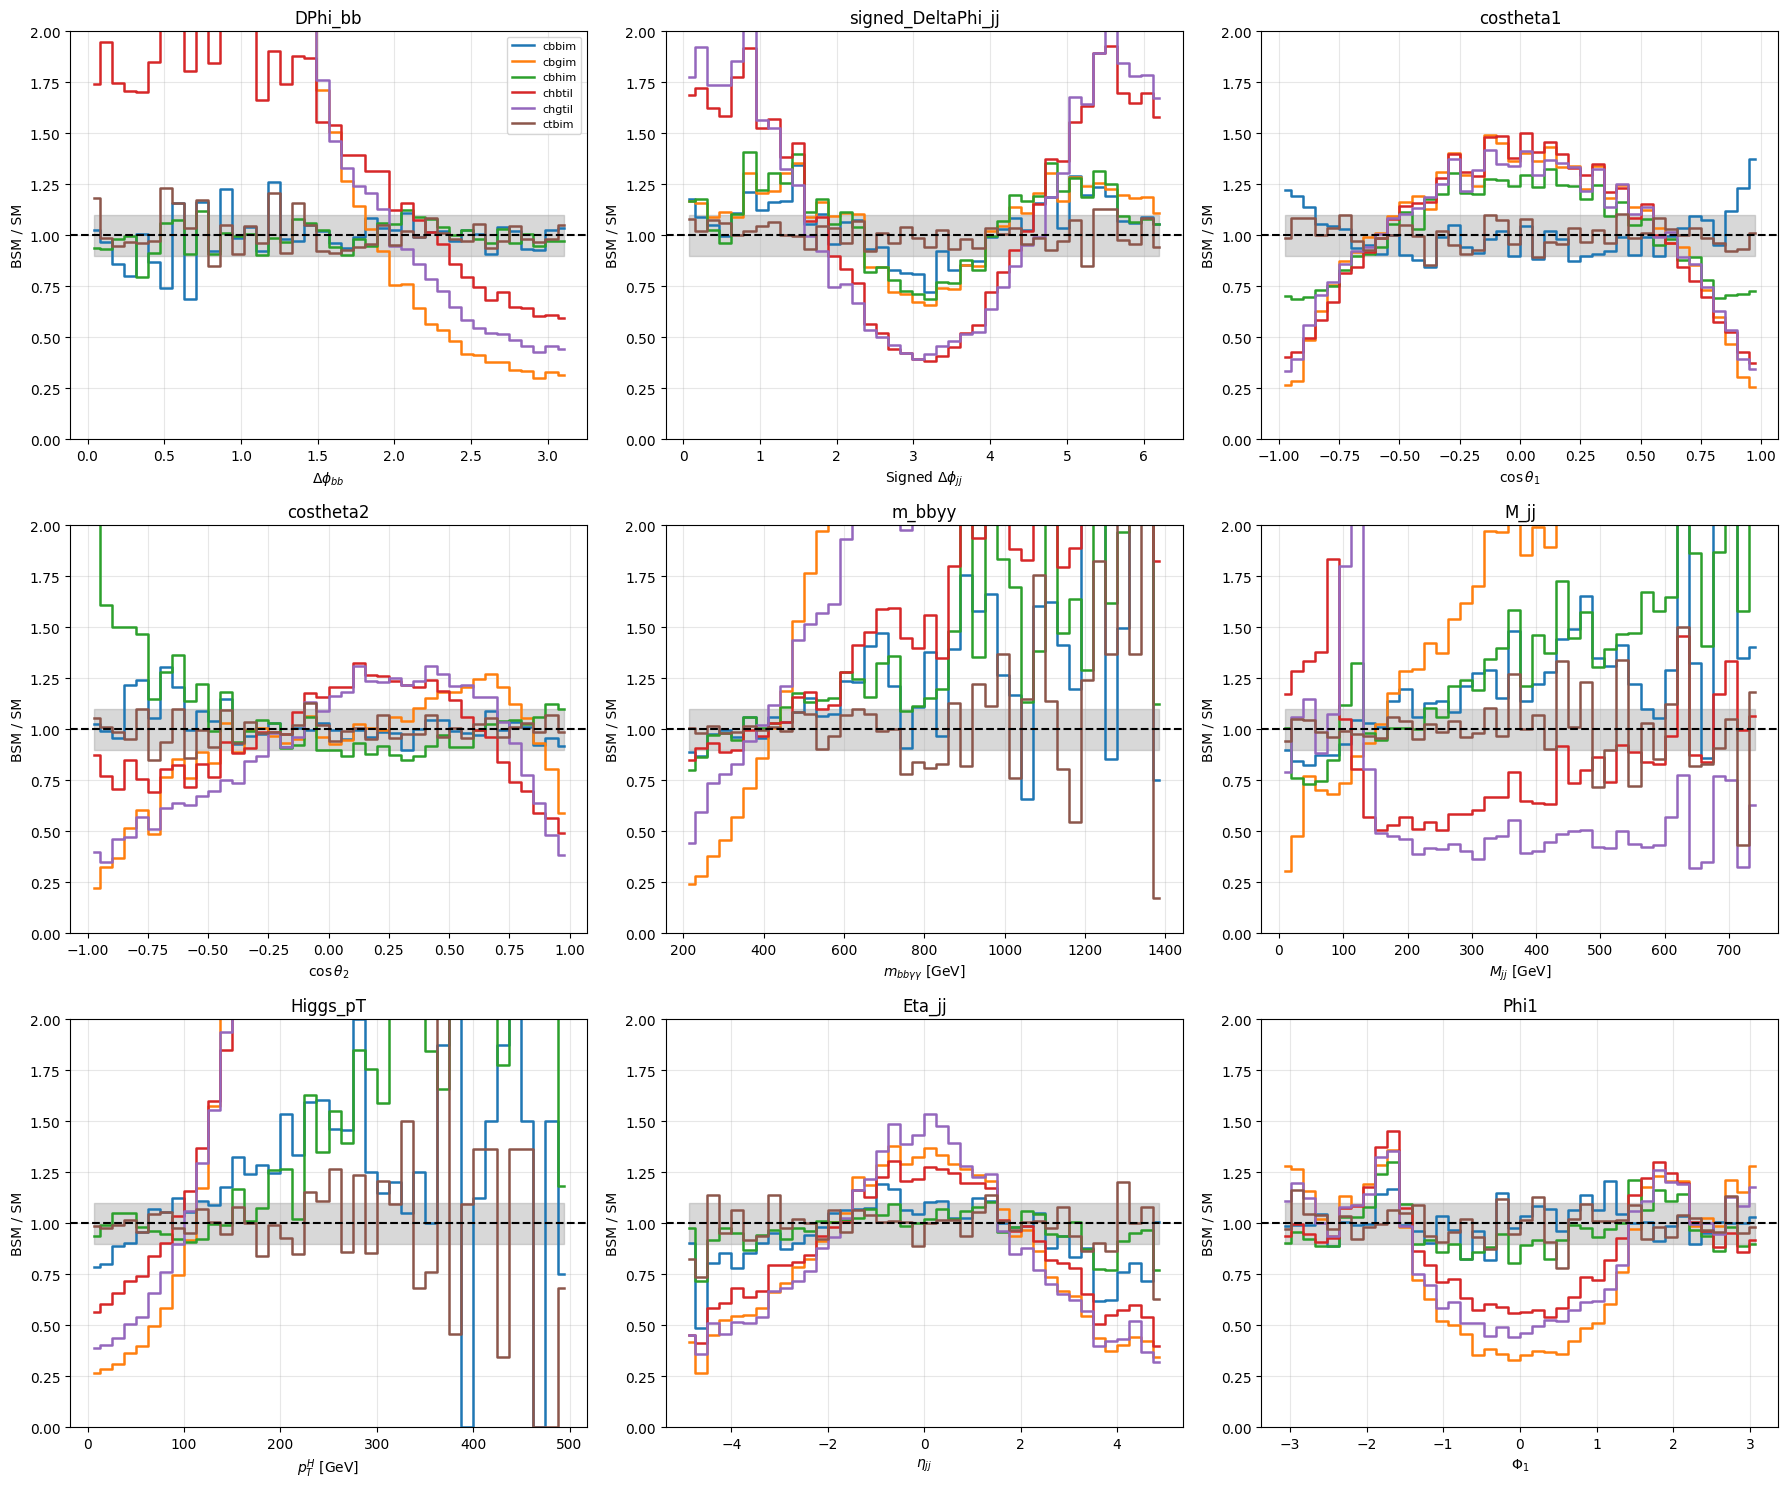

In [28]:
ratio_observables = [

    "DPhi_bb",
    "signed_DeltaPhi_jj",
    "costheta1",

    "costheta2",
    "m_bbyy",
    "M_jj",

    "Higgs_pT",
    "Eta_jj",
    "Phi1"
]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(18, 15)
)

axes = axes.flatten()

for idx, observable in enumerate(ratio_observables):

    ax = axes[idx]

    config = plot_configs[observable]

    x_range = config["range"]

    # --- SM histogram ---

    sm_hist, bin_edges = np.histogram(
        dfs["SM"][observable],
        bins=40,
        range=x_range,
        density=True
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # --- BSM ratios ---

    for label, df in dfs.items():

        if label == "SM":
            continue

        bsm_hist, _ = np.histogram(
            df[observable],
            bins=40,
            range=x_range,
            density=True
        )

        ratio = np.divide(
            bsm_hist,
            sm_hist,
            out=np.ones_like(bsm_hist),
            where=sm_hist > 0
        )

        ax.step(
            bin_centers,
            ratio,
            where="mid",
            linewidth=1.8,
            label=label
        )

    # unity line

    ax.axhline(
        1.0,
        linestyle="--",
        color="black"
    )

    # grey band

    ax.fill_between(
        bin_centers,
        0.9,
        1.1,
        color="gray",
        alpha=0.3
    )

    ax.set_xlabel(config["xlabel"])

    ax.set_ylabel("BSM / SM")

    ax.set_title(observable)

    ax.set_ylim(0, 2)

    ax.grid(alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()

plt.show()